In [15]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")

In [16]:
results = results[[
    "raceId", "driverId", "constructorId", "grid", "positionOrder"
]]

results["grid"] = pd.to_numeric(results["grid"], errors="coerce")
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors="coerce")

results = results.dropna()

df = results.merge(races, on="raceId", how="left")

df = df[(df["grid"] > 0) & (df["grid"] <= 20)]
df = df[df["positionOrder"] <= 20]

df = df.reset_index(drop=True)


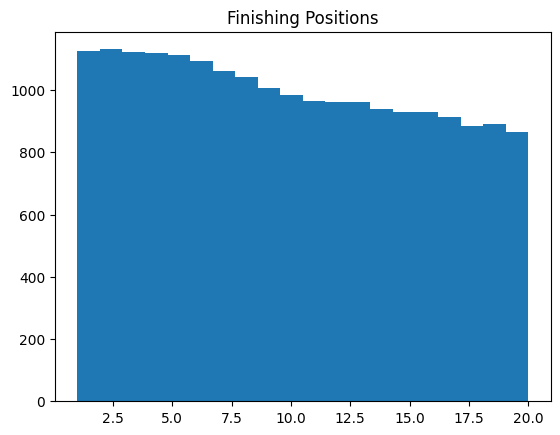

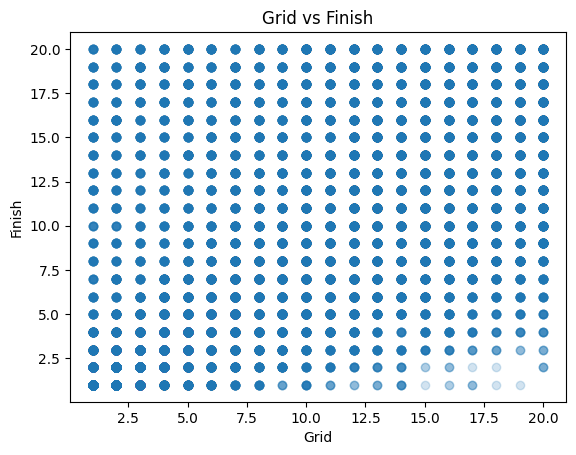

In [17]:
plt.hist(df["positionOrder"], bins=20)
plt.title("Finishing Positions")
plt.show()

plt.scatter(df["grid"], df["positionOrder"], alpha=0.2)
plt.xlabel("Grid")
plt.ylabel("Finish")
plt.title("Grid vs Finish")
plt.show()

In [18]:
df = df.sort_values(by=["driverId", "raceId"])

df["driver_form"] = (
    df.groupby("driverId")["positionOrder"]
      .rolling(5, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

df["constructor_form"] = (
    df.groupby("constructorId")["positionOrder"]
      .rolling(5, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

df["experience"] = df.groupby("driverId").cumcount()

In [19]:
df["top10"] = (df["positionOrder"] <= 10).astype(int)

In [25]:
X = df[[
    "grid",
    "driver_form",
    "constructor_form",
    "experience",
    "driverId"
]]
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X["driverId"] = le.fit_transform(X["driverId"])

y = df["top10"]

/tmp/ipykernel_699/2715338598.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["driverId"] = le.fit_transform(X["driverId"])


In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
df = df.sample(10000, random_state=42)

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.670993509735397


In [23]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[1127  712]
 [ 607 1560]]
